In [4]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import wandb
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import torchvision

import sys
sys.path.append('../src/')
from hierarchy_functions import *

symmetry_classes = ['p1', 'p2', 'p3']
label_converter = list_to_dict(symmetry_classes)

In [2]:
import h5py

In [5]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
label_converter

{0: 'p1',
 1: 'p2',
 2: 'pm',
 3: 'pg',
 4: 'cm',
 5: 'pmm',
 6: 'pmg',
 7: 'pgg',
 8: 'cmm',
 9: 'p4',
 10: 'p4m',
 11: 'p4g',
 12: 'p3',
 13: 'p3m1',
 14: 'p31m',
 15: 'p6',
 16: 'p6m'}

In [33]:
with h5py.File('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5') as h5_from:
    print(list(h5_from.keys()))
    print(h5_from['train'].keys())
    labels = np.array(h5_from['train']['labels'])
    data = np.array(h5_from['train']['data'])
print(labels)

['test', 'train', 'valid']
<KeysViewHDF5 ['data', 'labels', 'primitive_uc_vector_a', 'primitive_uc_vector_b', 'shapes', 'translation_start_point', 'translation_uc_vector_a', 'translation_uc_vector_b', 'unit_cell']>
[10 14 11 ...  7 12 12]


In [22]:
l = np.concatenate([labels[labels == 0], labels[labels == 1], labels[labels == 12]])
l

array([0, 0, 0, ..., 2, 2, 2], dtype=uint8)

In [38]:
with h5py.File('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5') as h5_from:
    with h5py.File('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_p1p2p3.h5', 'a') as h5_to:
        for k in list(h5_from.keys()):
            h5_to.create_group(k)
            
            labels = np.array(h5_from[k]['labels'])
            length = len(np.concatenate([labels[labels == 0], labels[labels == 1], labels[labels == 12]]))

            for kk in list(h5_from[k].keys()):
                
                data = np.array(h5_from[k][kk])
                sorted_data = np.concatenate([data[labels == 0], data[labels == 1], data[labels == 12]])
                h5_to[k].create_dataset(kk, data=sorted_data)

In [49]:
%load_ext autoreload
%autoreload 2
import os
import time
from tqdm import tqdm
import wandb
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
import torch.nn.functional as F

import sys
sys.path.append('../../../helper_functions/')
from visualization_functions import show_images

sys.path.append('../src/')
from h5_functions import list_to_dict, hdf5_dataset, viz_dataloader

from spatial_transformer_functions import Attention_affine_model_every_level
from train_functions import train_epochs

label_converter = {0:'p1', 1:'p2', 12:'p3'}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


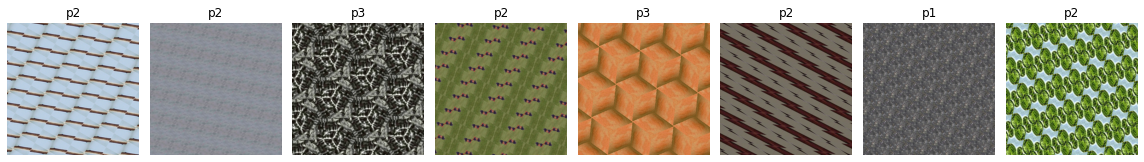

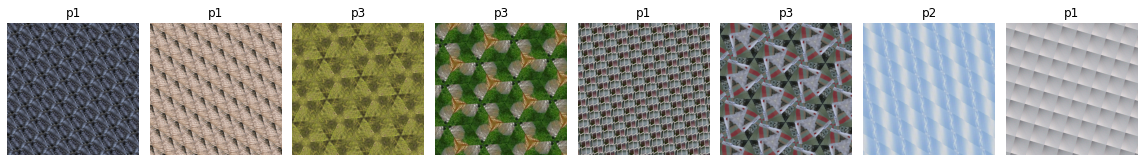

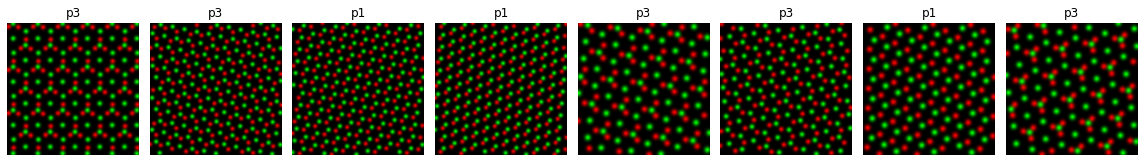

CPU times: user 2.55 s, sys: 566 ms, total: 3.11 s
Wall time: 6.28 s


In [50]:
%%time
# imagenet
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_p1p2p3.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=6)
viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_p1p2p3.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=True, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter)

test_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_p1p2p3.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=256, shuffle=True, num_workers=6)
viz_dataloader(test_dl, label_converter=label_converter)

In [51]:
model = models.resnet50()

model.fc = nn.Sequential(nn.BatchNorm1d(2048),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 2048, out_features=512, bias=False),
                         nn.ReLU(inplace=True),

                         nn.BatchNorm1d(512),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 512, out_features=64, bias=False),
                         nn.ReLU(inplace=True),
                         
                         nn.BatchNorm1d(64),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=64, out_features=17, bias=True)
                        )
model(torch.randn(2,3,256,256)).shape

torch.Size([2, 17])

torch.Size([2, 17])

In [78]:
config = {
    'dataset': '/scratch/yichen/imagenet_v4_rot_10m_5percent_subset_hierarchy_p1p2p3.h5',
    'device': torch.device('cuda:1'),
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = '10152023-hierarchy-resnet50_from_scratch-v4_2m_5percent_subset-p1p2p3'

# train

In [20]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [53]:
# os.environ["WANDB_NOTEBOOK_NAME"] = nb_name
wandb.init(project='symmetry_paper', entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [79]:
NAME

'10152023-hierarchy-resnet50_from_scratch-v4_2m_5percent_subset-p1p2p3'

In [54]:
device = config['device']
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_name=NAME, 
                       model_dir='/scratch/yichen/models_new/', tracking=True)

Epoch: 1/50


  0%|          | 0/70 [00:00<?, ?it/s]

100%|██████████| 70/70 [00:31<00:00,  2.21it/s]


Training: Loss: 3.1201, Accuracy: 4.6081%, Time: 0.5273mins


100%|██████████| 70/70 [00:13<00:00,  5.03it/s]


...

Training: Loss: 0.0045, Accuracy: 99.9269%, Time: 0.4694mins


100%|██████████| 70/70 [00:14<00:00,  4.76it/s]


Validation : Loss : 0.0762, Accuracy: 98.0725%, Time: 0.24mins


100%|██████████| 69/69 [00:14<00:00,  4.76it/s]


Validation : Loss : 5.3219, Accuracy: 54.9040%, Time: 0.24mins


# analyze

In [9]:
model = torch.load('/scratch/yichen/models_new/10152023-')

In [60]:
from confusion_matrix_functions import confusion_matrix, plot_cm

symmetry_classes = ['p1', 'p2', 'p3']
label_converter = {0:'p1', 1:'p2', 12:'p3'}

In [70]:
# imagenet 
def confusion_matrix(model, dataloader, classes, device, n_batches=1):
    model.eval()
    cm = torch.zeros(len(classes), len(classes))
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(tqdm(dataloader)):
            inputs = inputs.to(device) 
            labels = labels.to(device)
            model = model.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for t, p in zip(labels.view(-1), preds.view(-1)):
                if p.long().item() == 12: p = 2
                if t.long().item() == 12: t = 2
                cm[t, p] += 1
    cm = np.array(cm)

    print('Sum for true labels:')
    true_counts = np.expand_dims(np.sum(cm, axis=1), 0)
    display(pd.DataFrame(true_counts, columns=classes))

    wrong, right = 0, 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j: right+=cm[i,j]
            if i != j: wrong+=cm[i,j]
    print('Accuracy for these batches:', right/(right+wrong))
    return cm.astype(np.int32)

In [71]:
device = torch.device('cuda:1')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

  0%|          | 0/70 [00:00<?, ?it/s]

100%|██████████| 70/70 [00:15<00:00,  4.60it/s]

Sum for true labels:


,p1,p2,p3
0,6.0,17730.0,5914.0


Accuracy for these batches: 0.5000422832980973


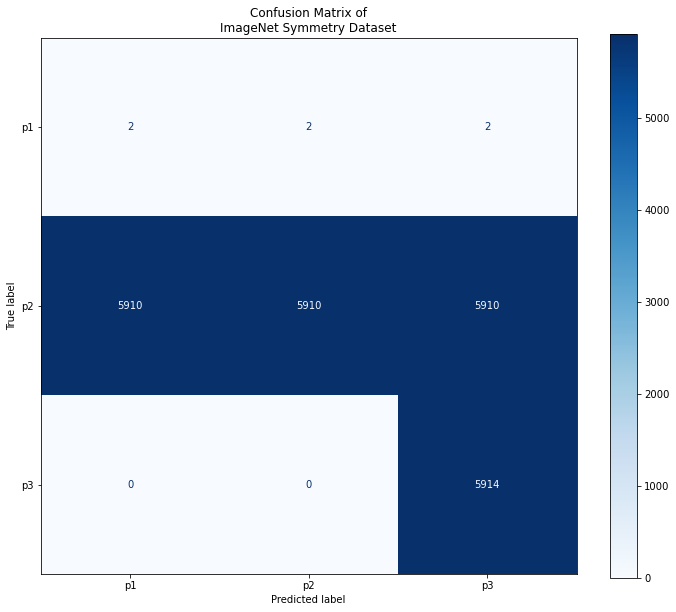

In [72]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [74]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 70/70 [00:16<00:00,  4.25it/s]

Sum for true labels:


,p1,p2,p3
0,504.0,17391.0,5955.0


Accuracy for these batches: 0.49924528301886795


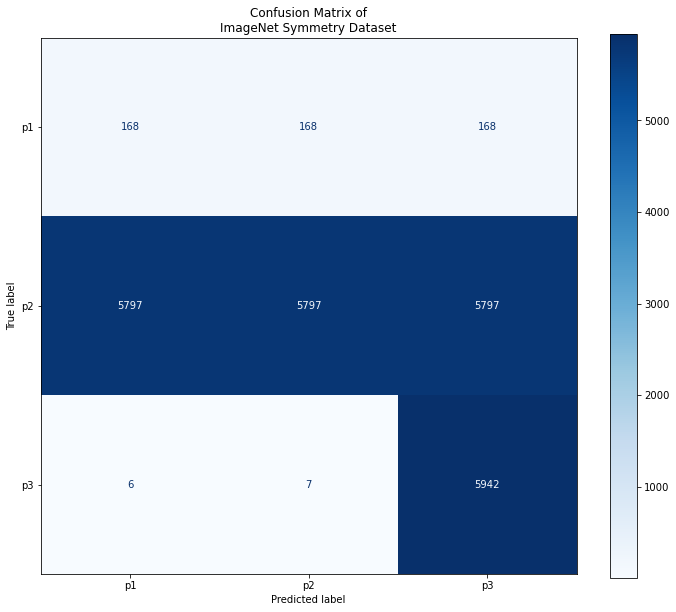

In [75]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [76]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

  0%|          | 0/69 [00:00<?, ?it/s]

100%|██████████| 69/69 [00:15<00:00,  4.34it/s]


Sum for true labels:


,p1,p2,p3
0,6084.0,11487.0,5969.0


Accuracy for these batches: 0.25050977060322854


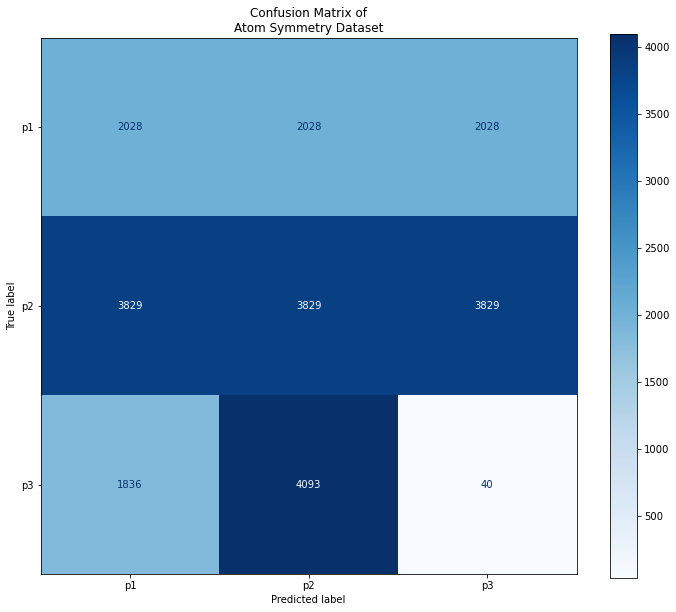

In [77]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
import sys
sys.path.append('../../../helper_functions/')
from python_email import send_email
send_email()

In [ ]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)
restartkernel()